## HuggingFace Vision Transformers 기반 시각 표현 학습

HuggingFace `transformers` 라이브러리의 **Vision Transformer(ViT)** 를 사용하여
제품 이미지의 **임베딩(Embedding)** 을 생성하고, **Cosine Similarity** 로 유사 제품을 찾는 예제.

| 섹션 | 내용 |
|------|------|
| Image Embedding | ViT hidden state 추출 및 CLS / Mean Pooling |
| Similarity 분석 | 임베딩 기반 Cosine Similarity 계산 및 시각화 |
| 실습 예제 | 제품 카탈로그에서 유사 제품 검색 (Image Retrieval) |

Classification Pooling(CLS Pooling)은 Transformer에서 [CLS] 토큰의 출력 벡터 하나를 전체 입력의 대표 벡터로 사용하는 방법이다.<br>
CLS Token은 원래 BERT 에서 문장 분류(Classification) 작업을 위해 만든 특별 토큰이다<br>
Mean Pooling은 모든 토큰 벡터의 평균을 내어 하나의 대표 벡터를 만드는 방법이다.<br>
> **실행 환경**: Google Colab (GPU 권장) 또는 로컬 Jupyter

### 1. 환경 설정 및 패키지 설치

In [1]:
# ========== 실행 환경 감지 ==========
# Google Colab 여부를 확인해, 이후 업로드/설치 셀 분기에 사용

try:
    import google.colab
    IN_COLAB = True
    print('Google Colab 환경에서 실행 중')
except ImportError:
    IN_COLAB = False
    print('로컬 Jupyter 환경에서 실행 중')


로컬 Jupyter 환경에서 실행 중


In [2]:
# ========== 패키지 설치 (최초 1회) ==========
# 터미널 또는 Colab 셀에서 아래 명령을 실행
# py -3.11 -m pip install --upgrade pip
# py -3.11 -m pip install -q transformers
# py -3.11 -m pip install pillow matplotlib seaborn requests


In [3]:
# ========== 라이브러리 import 및 공통 설정 ==========

import io
import logging
import os
from pathlib import Path
from typing import Literal

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import requests
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, AutoModel

# (1) GPU 사용 가능 시 cuda, 아니면 cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')


def setup_korean_font() -> str:
    """설치된 한글 폰트 중 첫 번째만 선택해 matplotlib에 적용."""
    available = {font.name for font in fm.fontManager.ttflist}
    candidates = [
        'Malgun Gothic',      # Windows
        'AppleGothic',        # macOS
        'NanumGothic',        # Linux / Colab
        'NanumBarunGothic',
        'Noto Sans CJK KR',
        'Noto Sans KR',
        'Gulim',
        'Dotum',
    ]
    for name in candidates:
        if name in available:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False
            return name

    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False
    return 'DejaVu Sans (한글 미지원)'


# (2) matplotlib 한글 폰트 설정 및 findfont 경고 억제
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
selected_font = setup_korean_font()
print(f'matplotlib 한글 폰트: {selected_font}')


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


사용 디바이스: cpu
matplotlib 한글 폰트: Malgun Gothic


### 2. HuggingFace ViT 모델 로드

`google/vit-base-patch16-224` 는 ImageNet-21k로 사전학습된 ViT-Base 모델입니다.<br>
입력 이미지는 224×224로 리사이즈되며, 출력 hidden state는 `[batch, 197, 768]` 형태입니다.
(197 = 1 CLS 토큰 + 196 패치 토큰)

In [4]:
# ========== HuggingFace ViT 모델 및 전처리기 로드 ==========

MODEL_NAME = 'google/vit-base-patch16-224'

# (1) 이미지 리사이즈·정규화 파라미터 (ImageNet mean/std)
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

# (2) ViT 본체 로드 → GPU/CPU 이동 → 추론 모드(eval)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f'모델: {MODEL_NAME}')
print(f'Hidden size: {model.config.hidden_size}')
# 최초 실행 시 HuggingFace Hub에서 가중치 다운로드 (약 30~40초)


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 9236.60it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델: google/vit-base-patch16-224
Hidden size: 768


### 3. Image Embedding: Pooling 구현

ViT의 마지막 hidden state에서 이미지 전체를 대표하는 **고정 길이 벡터**를 만드는 방법:

| Pooling | 설명 |
|---------|------|
| **CLS** | `[CLS]` 토큰(인덱스 0) 벡터 사용 — 분류 헤드와 동일한 방식 |
| **Mean** | 패치 토큰(인덱스 1~)의 평균 — 공간 정보를 전체적으로 반영 |

유사도 검색에서는 L2 정규화 후 Cosine Similarity를 사용합니다.

In [5]:
# ========== Image Embedding: Pooling 및 인코딩 함수 ==========

PoolingStrategy = Literal['cls', 'mean']


def pool_hidden_state(
    hidden_state: torch.Tensor,
    strategy: PoolingStrategy = 'cls',
) -> torch.Tensor:
    """ViT last_hidden_state → 이미지 임베딩 벡터.

    Args:
        hidden_state: [batch, seq_len, hidden_dim]
        strategy: 'cls' 또는 'mean'
    Returns:
        [batch, hidden_dim]
    """
    # (1) CLS pooling: [CLS] 토큰(인덱스 0) 벡터 사용
    if strategy == 'cls':
        return hidden_state[:, 0, :]
    # (2) Mean pooling: 패치 토큰(인덱스 1~) 평균
    if strategy == 'mean':
        return hidden_state[:, 1:, :].mean(dim=1)
    raise ValueError(f"지원하지 않는 pooling: {strategy}")


def encode_images(
    images: list[Image.Image],
    strategy: PoolingStrategy = 'cls',
    normalize: bool = True,
) -> torch.Tensor:
    """PIL 이미지 리스트 → 임베딩 텐서.

    Args:
        images: PIL Image 리스트
        strategy: pooling 방식
        normalize: L2 정규화 여부 (Cosine Similarity용)
    Returns:
        [N, hidden_dim] 임베딩
    """
    # (1) 전처리: 224x224 리사이즈 + 텐서 변환
    inputs = processor(images=images, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # (2) ViT forward → pooling → (선택) L2 정규화
    with torch.no_grad():
        outputs = model(**inputs)
        embeddings = pool_hidden_state(outputs.last_hidden_state, strategy=strategy)
        if normalize:
            embeddings = F.normalize(embeddings, p=2, dim=-1)
    return embeddings.cpu()


def encode_single_image(
    image: Image.Image,
    strategy: PoolingStrategy = 'cls',
    normalize: bool = True,
) -> torch.Tensor:
    """단일 이미지 임베딩. shape: [hidden_dim]"""
    return encode_images([image], strategy=strategy, normalize=normalize)[0]


### 4. 제품 이미지 데이터 준비

다양한 카테고리의 제품 이미지 12장을 URL에서 다운로드.
실무에서는 DB에 저장된 제품 썸네일 경로를 동일한 방식으로 처리.

In [6]:
# ========== 제품 카탈로그 정의 및 이미지 다운로드 ==========

# (1) 제품 메타데이터: id, 이름, 카테고리, 이미지 URL(복수 가능 — fallback)
PRODUCT_CATALOG = [
    {'id': 'P001', 'name': '러닝화 A',       'category': '신발', 'urls': ['https://images.unsplash.com/photo-1542291026-7eec264c27ff?w=400']},
    {'id': 'P002', 'name': '러닝화 B',       'category': '신발', 'urls': ['https://images.unsplash.com/photo-1606107557195-0e29a4b5b4aa?w=400']},
    {'id': 'P003', 'name': '캔버스 스니커즈', 'category': '신발', 'urls': ['https://images.unsplash.com/photo-1525966222134-fcfa99b8ae77?w=400']},
    {'id': 'P004', 'name': '가죽 부츠',       'category': '신발', 'urls': [
        'https://images.unsplash.com/photo-1605812860427-4024433a70fd?w=400',
        'https://images.unsplash.com/photo-1549298916-b41d501d3772?w=400',
    ]},
    {'id': 'P005', 'name': '백팩',           'category': '가방', 'urls': ['https://images.unsplash.com/photo-1553062407-98eeb64c6a62?w=400']},
    {'id': 'P006', 'name': '토트백',         'category': '가방', 'urls': [
        'https://images.unsplash.com/photo-1566150905458-1bf1fc113f0d?w=400',
        'https://images.unsplash.com/photo-1491637639811-60e2756cc1c7?w=400',
    ]},
    {'id': 'P007', 'name': '크로스백',       'category': '가방', 'urls': ['https://images.unsplash.com/photo-1548036328-c9fa89d128fa?w=400']},
    {'id': 'P008', 'name': '스마트폰',       'category': '전자', 'urls': ['https://images.unsplash.com/photo-1511707171634-5f897ff02aa9?w=400']},
    {'id': 'P009', 'name': '노트북',         'category': '전자', 'urls': ['https://images.unsplash.com/photo-1496181133206-80ce9b88a853?w=400']},
    {'id': 'P010', 'name': '무선 이어폰',     'category': '전자', 'urls': ['https://images.unsplash.com/photo-1590658268037-6bf12165a8df?w=400']},
    {'id': 'P011', 'name': '면 티셔츠',       'category': '의류', 'urls': ['https://images.unsplash.com/photo-1521572163474-6864f9cf17ab?w=400']},
    {'id': 'P012', 'name': '데님 자켓',       'category': '의류', 'urls': ['https://images.unsplash.com/photo-1551028719-00167b16eac5?w=400']},
]

# (2) 로컬 저장 폴더 (재실행 시 캐시된 이미지 재사용)
SAVE_DIR = Path('product_images')
SAVE_DIR.mkdir(exist_ok=True)


def download_image(urls: str | list[str], save_path: Path, timeout: int = 15) -> Image.Image:
    """URL(또는 URL 목록)에서 이미지를 다운로드하고 RGB PIL Image로 반환."""
    if isinstance(urls, str):
        urls = [urls]

    # 이미 저장된 파일이 있으면 재다운로드 생략
    if save_path.exists():
        try:
            return Image.open(save_path).convert('RGB')
        except Exception:
            save_path.unlink(missing_ok=True)

    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    last_error: Exception | None = None

    # fallback URL 순차 시도
    for url in urls:
        try:
            response = requests.get(url, headers=headers, timeout=timeout)
            response.raise_for_status()
            image = Image.open(io.BytesIO(response.content)).convert('RGB')
            image.save(save_path)
            return image
        except Exception as exc:
            last_error = exc
            print(f'  [경고] 다운로드 실패 → 다음 URL 시도: {url}')

    raise RuntimeError(f'이미지 다운로드 실패 ({save_path.name}): {last_error}')


# (3) 카탈로그 전체 이미지 로드 및 라벨 생성
product_images: list[Image.Image] = []
product_labels: list[str] = []

for item in PRODUCT_CATALOG:
    save_path = SAVE_DIR / f"{item['id']}.jpg"
    img = download_image(item['urls'], save_path)
    product_images.append(img)
    product_labels.append(f"{item['id']} | {item['name']} ({item['category']})")

print(f'제품 이미지 {len(product_images)}장 로드 완료')


제품 이미지 12장 로드 완료


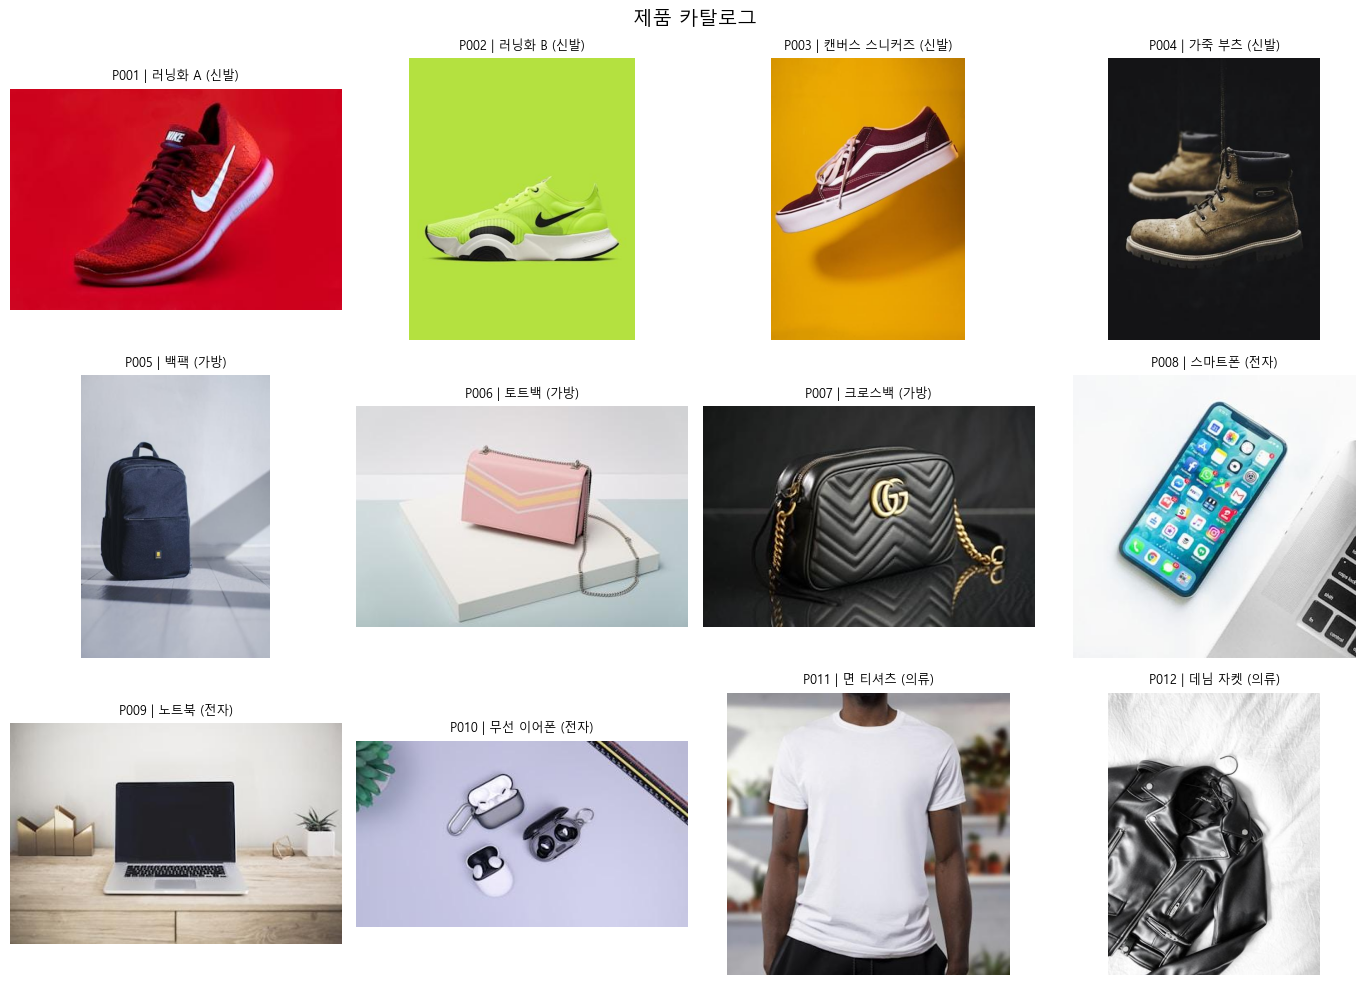

In [7]:
# ========== 제품 카탈로그 미리보기 ==========
# 12개 제품을 3x4 그리드로 시각화

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, img, label in zip(axes.ravel(), product_images, product_labels):
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('제품 카탈로그', fontsize=14)
plt.tight_layout()
plt.show()


### 5. 제품 이미지 임베딩 생성

In [8]:
# ========== 제품 이미지 임베딩 생성 ==========

POOLING = 'cls'  # 'cls' 또는 'mean'

# (1) 12장 이미지 → [12, 768] 임베딩 행렬
product_embeddings = encode_images(product_images, strategy=POOLING, normalize=True)

# (2) shape 및 L2 정규화 확인 (norm ≈ 1.0)
print(f'임베딩 shape: {product_embeddings.shape}')  # [12, 768]
print(f'L2 norm (정규화 확인): {product_embeddings[0].norm():.4f}')


임베딩 shape: torch.Size([12, 768])
L2 norm (정규화 확인): 1.0000


### 6. Cosine Similarity 계산

L2 정규화된 벡터 $a, b$ 에 대해:

$$\text{cosine\_sim}(a, b) = \frac{a \cdot b}{\|a\| \|b\|} = a \cdot b \quad (\|a\|=\|b\|=1)$$


| 기호 | 의미 |
|------|------|
| $A \cdot B$ | 벡터 내적 (dot product) |
| $\|\|A\|\|$ | 벡터 크기 (norm) |
| $\cos(A, B)$ | 두 벡터 방향 유사도 |


값이 **1에 가까울수록** 시각적으로 유사하고, **0에 가까우면** 무관하다.

In [9]:
# ========== Cosine Similarity 계산 함수 및 예시 ==========

def cosine_similarity_matrix(embeddings: torch.Tensor) -> torch.Tensor:
    """[N, D] L2 정규화 임베딩 → [N, N] cosine similarity 행렬 (내적)."""
    return embeddings @ embeddings.T


def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> float:
    """두 벡터 간 cosine similarity (스칼라)."""
    a_norm = F.normalize(a.unsqueeze(0), p=2, dim=-1)
    b_norm = F.normalize(b.unsqueeze(0), p=2, dim=-1)
    return float((a_norm @ b_norm.T).item())


# (1) 전체 제품 간 유사도 행렬 계산
sim_matrix = cosine_similarity_matrix(product_embeddings)
print('유사도 행렬 shape:', sim_matrix.shape)

# (2) 같은 카테고리 vs 다른 카테고리 유사도 비교
print(f'P001 ↔ P002 (같은 카테고리·신발): {sim_matrix[0, 1]:.4f}')
print(f'P001 ↔ P008 (다른 카테고리):       {sim_matrix[0, 7]:.4f}')


유사도 행렬 shape: torch.Size([12, 12])
P001 ↔ P002 (같은 카테고리·신발): 0.4143
P001 ↔ P008 (다른 카테고리):       0.0466


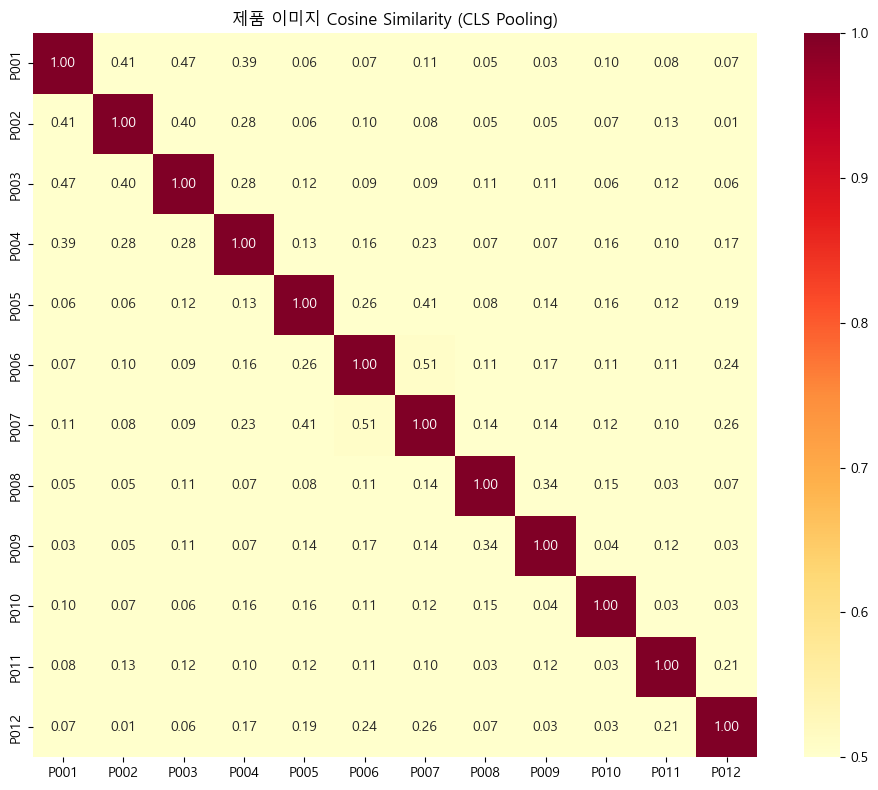

In [10]:
# ========== Cosine Similarity 히트맵 시각화 ==========

short_labels = [item['id'] for item in PRODUCT_CATALOG]

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix.numpy(),
    xticklabels=short_labels,
    yticklabels=short_labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0.5,
    vmax=1.0,
    square=True,
)
plt.title(f'제품 이미지 Cosine Similarity ({POOLING.upper()} Pooling)')
plt.tight_layout()
plt.show()


### 7. 유사 제품 검색 (Image Retrieval)

쿼리 이미지 1장을 입력하면 카탈로그에서 **Top-K 유사 제품**을 반환.<br>
이커머스에서 "비슷한 상품 보기", "이 상품과 함께 본 상품" 추천의 기본 원리이다.

In [11]:
# ========== 유사 제품 검색(Image Retrieval) 함수 ==========

def search_similar_products(
    query_image: Image.Image,
    catalog_embeddings: torch.Tensor,
    catalog_labels: list[str],
    top_k: int = 5,
    strategy: PoolingStrategy = 'cls',
    exclude_self: bool = False,
    query_idx: int | None = None,
) -> list[tuple[str, float]]:
    """쿼리 이미지와 유사한 제품 Top-K 반환.

    Returns:
        [(label, similarity_score), ...] 내림차순 정렬
    """
    # (1) 쿼리 이미지 임베딩 생성
    query_emb = encode_single_image(query_image, strategy=strategy, normalize=True)

    # (2) 카탈로그 임베딩과 내적 → 유사도 점수
    scores = catalog_embeddings @ query_emb  # [N]

    # (3) 점수 내림차순 Top-K 추출 (자기 자신 제외 옵션)
    ranked = scores.argsort(descending=True)
    results = []
    for idx in ranked:
        idx = int(idx)
        if exclude_self and query_idx is not None and idx == query_idx:
            continue
        results.append((catalog_labels[idx], float(scores[idx])))
        if len(results) >= top_k:
            break
    return results


def visualize_search_results(
    query_image: Image.Image,
    query_title: str,
    results: list[tuple[str, float]],
    catalog_images: list[Image.Image],
    catalog_labels: list[str],
):
    """검색 결과를 Query + Top-K 이미지 그리드로 시각화."""
    n = len(results) + 1
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))

    # 쿼리 이미지
    axes[0].imshow(query_image)
    axes[0].set_title(f'Query\n{query_title}', fontsize=9)
    axes[0].axis('off')

    # Top-K 유사 제품
    for ax, (label, score) in zip(axes[1:], results):
        idx = catalog_labels.index(label)
        ax.imshow(catalog_images[idx])
        ax.set_title(f'{score:.3f}\n{label}', fontsize=8)
        ax.axis('off')

    plt.suptitle('유사 제품 검색 결과 (Cosine Similarity)', fontsize=12)
    plt.tight_layout()
    plt.show()


=== Top-5 유사 제품 ===
1. P003 | 캔버스 스니커즈 (신발)  →  0.4728
2. P002 | 러닝화 B (신발)  →  0.4143
3. P004 | 가죽 부츠 (신발)  →  0.3858
4. P007 | 크로스백 (가방)  →  0.1063
5. P010 | 무선 이어폰 (전자)  →  0.1001


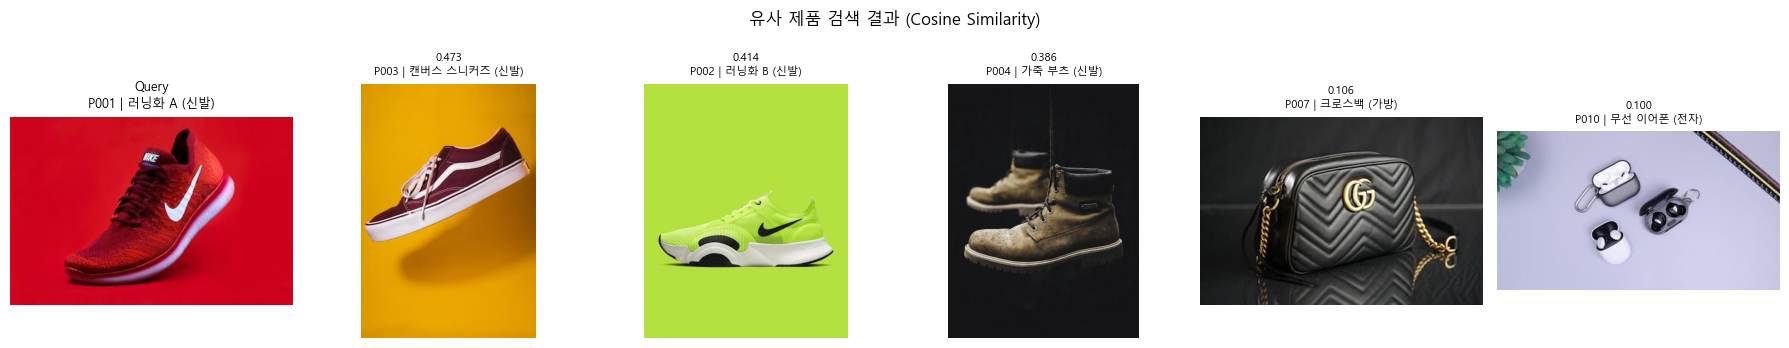

In [12]:
# ========== 유사 제품 검색 예시 1: 러닝화(P001) ==========
# 기대: 신발 카테고리(P002, P003, P004)가 상위에 랭크

QUERY_IDX = 0
query_img = product_images[QUERY_IDX]
query_label = product_labels[QUERY_IDX]

results = search_similar_products(
    query_img,
    product_embeddings,
    product_labels,
    top_k=5,
    strategy=POOLING,
    exclude_self=True,
    query_idx=QUERY_IDX,
)

print('=== Top-5 유사 제품 ===')
for rank, (label, score) in enumerate(results, 1):
    print(f'{rank}. {label}  →  {score:.4f}')

visualize_search_results(query_img, query_label, results, product_images, product_labels)


=== Top-5 유사 제품 ===
1. P009 | 노트북 (전자)  →  0.3408
2. P010 | 무선 이어폰 (전자)  →  0.1543
3. P007 | 크로스백 (가방)  →  0.1351
4. P006 | 토트백 (가방)  →  0.1134
5. P003 | 캔버스 스니커즈 (신발)  →  0.1105


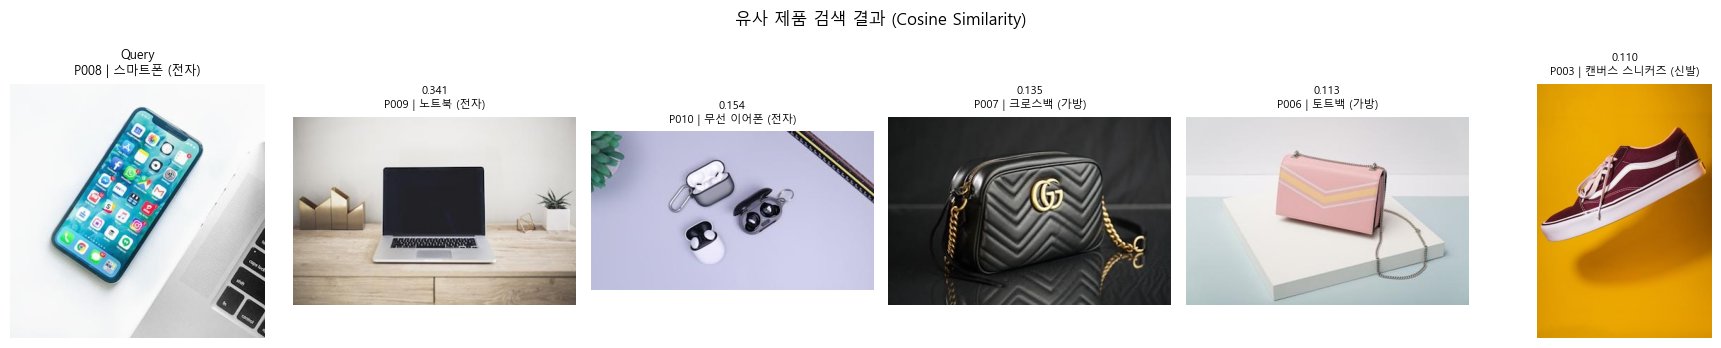

In [13]:
# ========== 유사 제품 검색 예시 2: 스마트폰(P008) ==========
# 기대: 전자 카테고리(P009, P010)가 상위에 랭크

QUERY_IDX = 7
query_img = product_images[QUERY_IDX]
query_label = product_labels[QUERY_IDX]

results = search_similar_products(
    query_img,
    product_embeddings,
    product_labels,
    top_k=5,
    strategy=POOLING,
    exclude_self=True,
    query_idx=QUERY_IDX,
)

print('=== Top-5 유사 제품 ===')
for rank, (label, score) in enumerate(results, 1):
    print(f'{rank}. {label}  →  {score:.4f}')

visualize_search_results(query_img, query_label, results, product_images, product_labels)


### 8. Pooling 방식 비교: CLS vs Mean

동일한 제품 카탈로그에 대해 두 pooling 방식의 유사도 분포를 비교한다.

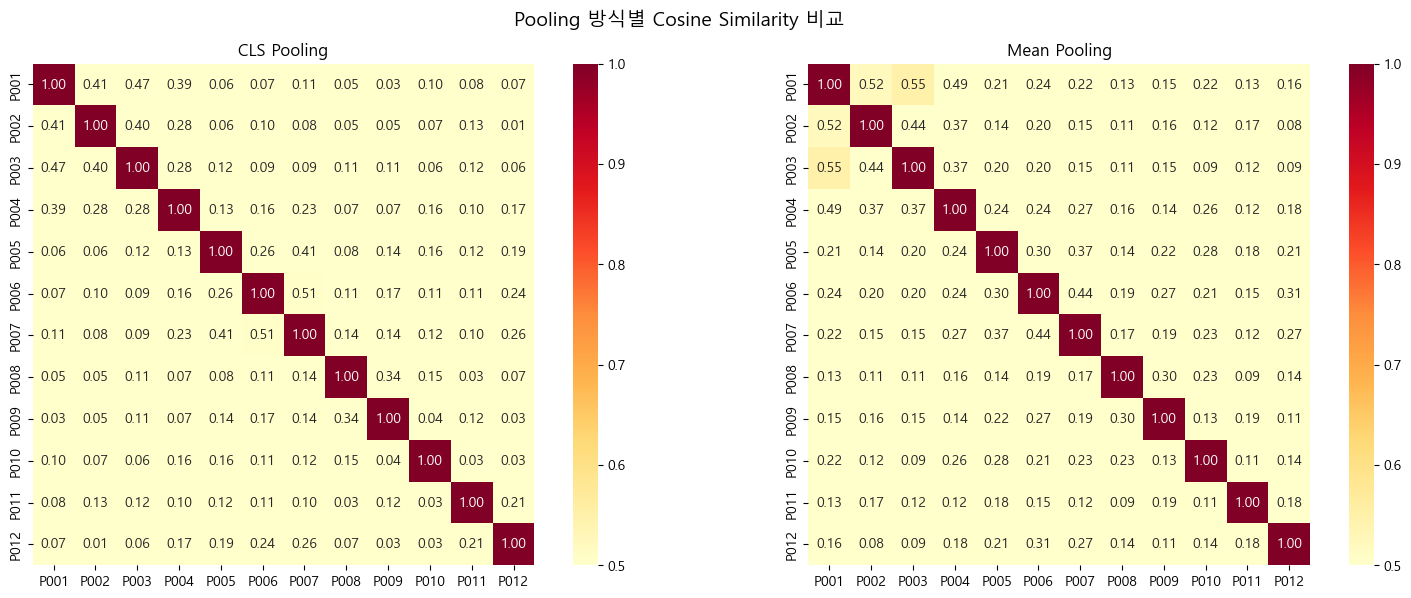

CLS  — 평균 유사도: 0.1457
Mean — 평균 유사도: 0.2109


In [14]:
# ========== Pooling 방식 비교: CLS vs Mean ==========

# (1) 두 pooling 방식으로 각각 임베딩 생성
emb_cls = encode_images(product_images, strategy='cls', normalize=True)
emb_mean = encode_images(product_images, strategy='mean', normalize=True)

# (2) 유사도 행렬 계산
sim_cls = cosine_similarity_matrix(emb_cls)
sim_mean = cosine_similarity_matrix(emb_mean)

# (3) 히트맵 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = [item['id'] for item in PRODUCT_CATALOG]

for ax, sim, title in zip(
    axes,
    [sim_cls, sim_mean],
    ['CLS Pooling', 'Mean Pooling'],
):
    sns.heatmap(
        sim.numpy(),
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        vmin=0.5,
        vmax=1.0,
        square=True,
        ax=ax,
    )
    ax.set_title(title)

plt.suptitle('Pooling 방식별 Cosine Similarity 비교', fontsize=14)
plt.tight_layout()
plt.show()

# (4) 자기 자신(대각선) 제외 평균 유사도 비교
n = sim_cls.shape[0]
mask = ~np.eye(n, dtype=bool)
print(f'CLS  — 평균 유사도: {sim_cls.numpy()[mask].mean():.4f}')
print(f'Mean — 평균 유사도: {sim_mean.numpy()[mask].mean():.4f}')


### 9. (선택) Colab에서 직접 이미지 업로드하여 검색

In [15]:
# ========== (선택) Colab 이미지 업로드 검색 ==========
# Colab에서 사용자 이미지를 업로드해 카탈로그와 유사도 비교

if IN_COLAB:
    from google.colab import files

    print('검색할 제품 이미지를 업로드하세요 (jpg/png).')
    uploaded = files.upload()

    if uploaded:
        filename = next(iter(uploaded))
        user_image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')

        user_results = search_similar_products(
            user_image,
            product_embeddings,
            product_labels,
            top_k=5,
            strategy=POOLING,
        )

        print('=== 업로드 이미지 기준 Top-5 ===')
        for rank, (label, score) in enumerate(user_results, 1):
            print(f'{rank}. {label}  →  {score:.4f}')

        visualize_search_results(
            user_image, '업로드 이미지', user_results, product_images, product_labels
        )
else:
    print('Colab이 아닌 환경에서는 이 셀을 건너뛰거나, 로컬 이미지 경로로 대체하세요.')
    # 로컬 예시:
    # user_image = Image.open('my_product.jpg').convert('RGB')
    # results = search_similar_products(user_image, product_embeddings, product_labels, top_k=5)


Colab이 아닌 환경에서는 이 셀을 건너뛰거나, 로컬 이미지 경로로 대체하세요.


### 10. 정리

이 노트북에서 다룬 핵심 개념:

1. **HuggingFace ViT** — `AutoModel` + `AutoImageProcessor`로 사전학습 모델을 즉시 활용
2. **Image Embedding** — `last_hidden_state`에서 CLS / Mean pooling으로 고정 길이 벡터 생성
3. **L2 정규화** — Cosine Similarity 계산을 내적(dot product)으로 단순화
4. **유사 제품 검색** — 쿼리 임베딩 × 카탈로그 임베딩 행렬로 Top-K retrieval

**실무 확장 아이디어**
- 임베딩을 FAISS / Milvus 등 벡터 DB에 저장하여 대규모 카탈로그 검색
- `facebook/dinov2-base` 등 self-supervised ViT로 교체하여 검색 품질 향상
- Contrastive Learning(CLIP)으로 텍스트+이미지 멀티모달 검색 구현